In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import glob
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)

In [87]:
csv_files = glob.glob("MovementAAL_RSS_*.csv")

In [88]:
print("Number of RSS files:",len(csv_files))
print(csv_files[:5])

Number of RSS files: 314
['MovementAAL_RSS_184.csv', 'MovementAAL_RSS_190.csv', 'MovementAAL_RSS_147.csv', 'MovementAAL_RSS_153.csv', 'MovementAAL_RSS_97.csv']


## Load Data Set

In [89]:
Target = pd.read_csv("MovementAAL_target.csv")
Target.head()

,#sequence_ID,class_label
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


In [90]:
Target.shape

(314, 2)

In [91]:
rss = pd.read_csv(csv_files[0],header=None)
rss.head()

,0,1,2,3
0,#RSS_anchor1,RSS_anchor2,RSS_anchor3,RSS_anchor4
1,-0.73333,-0.025641,-0.090909,-0.14286
2,0.11111,0.23077,-0.18182,-0.14286
3,0.11111,0.025641,-0.045455,-0.14286
4,0.11111,-0.076923,0.090909,0.095238


In [92]:
print(Target.columns)

Index(['#sequence_ID', ' class_label'], dtype='object')


In [93]:
Target.columns = Target.columns.str.strip()
print(Target.columns)

Index(['#sequence_ID', 'class_label'], dtype='object')


In [94]:
data = []

for i, file in enumerate(sorted(csv_files)):
    df = pd.read_csv(file)

    features = {
        "mean_1": df.iloc[:,0].mean(),
        "mean_2": df.iloc[:,1].mean(),
        "mean_3": df.iloc[:,2].mean(),
        "mean_4": df.iloc[:,3].mean(),

        "std_1": df.iloc[:,0].std(),
        "std_2": df.iloc[:,1].std(),
        "std_3": df.iloc[:,2].std(),
        "std_4": df.iloc[:,3].std(),

        "label": Target.iloc[i]["class_label"]
    }

    data.append(features)

dataset = pd.DataFrame(data)

dataset.head()

,mean_1,mean_2,mean_3,mean_4,std_1,std_2,std_3,std_4,label
0,-0.232805,-0.082963,-0.077601,0.088889,0.216344,0.185614,0.240700,0.299465,1
1,-0.066666,-0.136000,-0.140953,0.066000,0.162068,0.215097,0.246089,0.210515,1
2,0.188312,0.167273,-0.757576,-0.777273,0.200677,0.233446,0.268533,0.239904,1
3,0.285714,0.096000,-0.695238,-0.722500,0.240340,0.272656,0.232977,0.196331,1
4,0.314700,0.490435,-0.639752,-0.689130,0.251871,0.283412,0.201942,0.235467,1


## Split Features And Labels

In [95]:
X = dataset.drop("label",axis=1)
Y = dataset["label"]

In [96]:
X.shape, Y.shape

((314, 8), (314,))

## Split Training And Testing Data

In [97]:
x_train,x_test,y_train,y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify=Y )

In [98]:
x_train.shape, x_test.shape

((251, 8), (63, 8))

## Train Random Forest

In [99]:
model = RandomForestClassifier(n_estimators = 100, random_state = 42)

### Make Prediction

In [100]:
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [101]:
y_pred = model.predict(x_test)
print(y_pred[:10])

[-1 -1 -1 -1 -1 -1 -1 -1 -1  1]


### Check Accuracy

In [102]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7301587301587301


### Evaluate The Model

In [103]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[23  8]
 [ 9 23]]


In [104]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          -1       0.72      0.74      0.73        31
           1       0.74      0.72      0.73        32

    accuracy                           0.73        63
   macro avg       0.73      0.73      0.73        63
weighted avg       0.73      0.73      0.73        63



### Plot The Confusion Matrix

<Axes: >

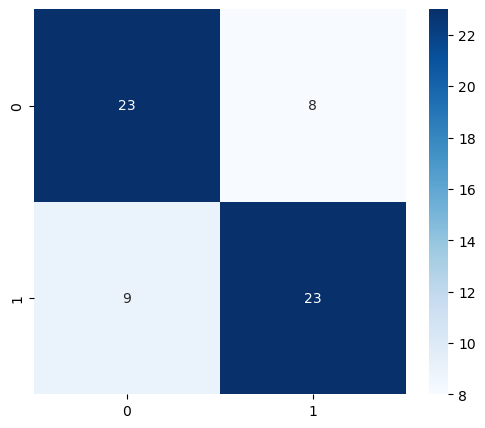

In [105]:
plt.figure(figsize = (6,5))
sb.heatmap(cm, annot=True, fmt="d", cmap="Blues")

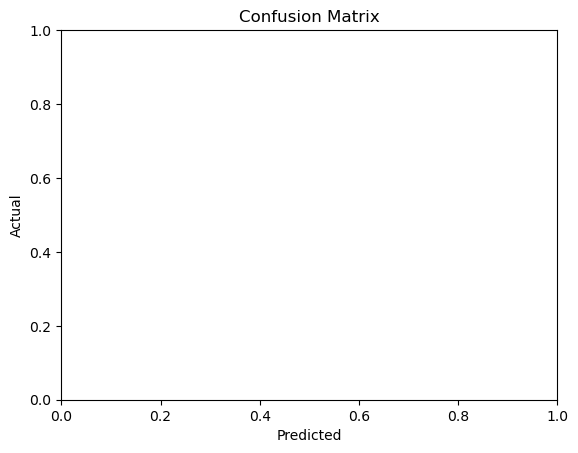

In [106]:
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

In [107]:
importance = pd.DataFrame({"Feature": X.columns, 
              "Importance": model.feature_importances_})

importance = importance.sort_values(by="Importance",ascending = False)

print(importance)

  Feature  Importance
2  mean_3    0.151205
0  mean_1    0.143924
1  mean_2    0.135678
6   std_3    0.129765
4   std_1    0.117474
3  mean_4    0.115614
5   std_2    0.109247
7   std_4    0.097094


## Save The Model

In [108]:
joblib.dump(model, "wifi_presence_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully
